In [1]:
import os, sys

notebook_dir = os.getcwd()

#add path
sys.path.append(os.path.abspath(os.path.join(notebook_dir, '..')))

In [2]:
from scripts.data_preprocessing import *
from scripts.modeling import *
from scripts.loss_function import *
from scripts.post_analysis import *
from scripts.model_serialization import *
from scripts.deep_learning import *
from scripts.hyperparameter import *
import pandas as pd

In [3]:
dataTr = '../../Data/rossmann-store-sales/train.csv'
dataSt = '../../Data/rossmann-store-sales/store.csv'
dataTs = '../../Data/rossmann-store-sales/test.csv'
dataSa = '../../Data/rossmann-store-sales/sample_submission.csv'

data1 = pd.read_csv(dataTr, low_memory=False)
data2 = pd.read_csv(dataSt, low_memory=False)
data3 = pd.read_csv(dataTs, low_memory=False)
data4 = pd.read_csv(dataSa)

# Merge train and store data
train_merged = data1.merge(data2, on='Store', how='left')

# Merge test and store data
test_merged = data3.merge(data2, on='Store', how='left')

# print(data1.columns)
# print(data2.columns)
# print(data3.columns)
# print(data4.columns)

# 2.1 Preprocessing
processed_data = preprocess_data(train_merged)

# print(processed_data.columns)
# print(processed_data2.columns)

# Split into features and target
X = processed_data.drop('Sales', axis=1)
y = processed_data['Sales']

# print(X.shape)
# print(y.shape)

X_sample = X.sample(n=10000, random_state=42)  # Sample 10000 rows
y_sample = y[X_sample.index]  # Ensure y matches the sample

# # 2.2 Building models with sklearn pipelines
# model = build_model(X, y)
model, X_test, y_test = build_model(X_sample, y_sample)
model

# # 2.3 Choose a loss function
loss_function = define_loss_function(y_test, model.predict(X_test))
loss_function




639.7185349999999

In [5]:
# 2.4 Post Prediction Analysis
feature_importance, confidence_intervals = analyze_predictions(model, X_test, y_test)


In [6]:
# # 2.5 Serialize models
serialize_model(model)

# # 2.6 Building model with deep learning
lstm_model = build_lstm_model(X)

c:\Users\pc\Desktop\10_Academy\Week-4\kaim-week-4\.myvenv4\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


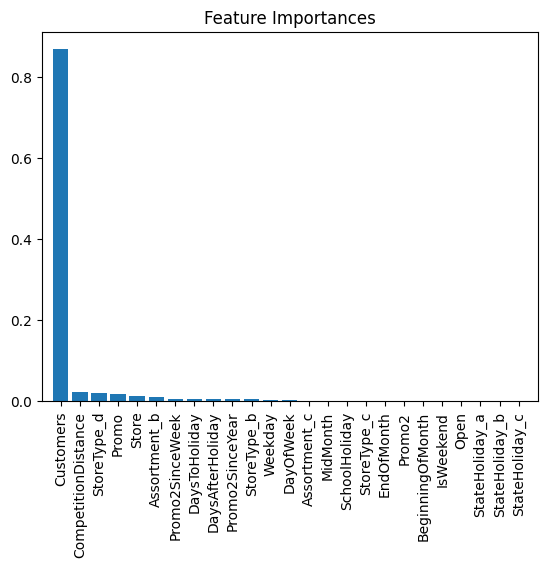

In [6]:
# Assuming `model` is your trained pipeline and `X` is your feature set
plot_feature_importance(model.named_steps['regressor'], X.columns)

In [7]:
predictions = model.predict(X_test)
lower_bound, upper_bound = estimate_confidence_interval(predictions)

print(f"Confidence interval: ({lower_bound}, {upper_bound})")

Confidence interval: (5745.510414442799, 6061.294695557202)


In [8]:
# Example usage
# Assuming `train_data` is your DataFrame containing the training data
best_model, mse, best_params = hyperparameter_tuning(processed_data)
print("Best Model Parameters:", best_params)
print("Mean Squared Error on Test Set:", mse)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


KeyboardInterrupt: 

In [ ]:
# # 2.1 Preprocessing
# processed_data2 = preprocess_data(test_merged)

# # Ensure the features match those used during training
# X2 = processed_data2

# # Make predictions
# predictions = model.predict(X2)
